In [3]:
import sys
from pathlib import Path

# Add project root (the directory that contains "src") to sys.path
root = Path().resolve()
while True:
    if (root / "src").is_dir():
        break
    if root.parent == root:
        root = Path.cwd()
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.anomaly_detection import detect_anomalies  # noqa: F401

In [13]:
import pandas as pd

if 'climate_df' not in globals():
    # Use existing candidates/root if present, else define defaults
    try:
        candidates  # ensure variable exists
    except NameError:
        candidates = [
            root / "data" / "climate.csv",
            root / "data" / "processed" / "climate.csv",
            root / "data" / "climate_df.csv",
            root / "data" / "processed" / "climate_df.csv",
            root / "notebooks" / "climate.csv",
        ]

    for p in candidates:
        if p.exists():
            climate_df = pd.read_csv(p)
            break
    else:
        # Try a broader search for files named like "climate*.csv" under the project root
        for p in root.rglob("climate*.csv"):
            try:
                df = pd.read_csv(p)
            except Exception:
                continue
            climate_df = df
            break
        else:
            # Fallback: try any CSV and pick the first plausible one
            for p in root.rglob("*.csv"):
                try:
                    df = pd.read_csv(p)
                except Exception:
                    continue
                cols = {c.lower() for c in df.columns}
                if {"date"}.issubset(cols) or cols & {"year", "temperature", "anomaly", "temp"} or df.shape[1] >= 2:
                    climate_df = df
                    break
            else:
                raise NameError(f"climate_df is not defined and no candidate CSV was found; checked: {candidates}")

# Rename the anomaly column to match what detect_anomalies expects
climate_df_prepared = climate_df.rename(columns={'J-D': 'Temperature_Anomaly'})
anomaly_df = detect_anomalies(climate_df_prepared)
anomaly_df.head()


,Year,Temperature_Anomaly,Z_Score,Anomaly
0,1880,-0.18,NaN,False
1,1881,-0.09,NaN,False
2,1882,-0.11,NaN,False
3,1883,-0.18,NaN,False
4,1884,-0.29,NaN,False


In [15]:
anomaly_df = detect_anomalies(climate_df_prepared)
anomaly_df.head()

anomaly_df.head()

,Year,Temperature_Anomaly,Z_Score,Anomaly
0,1880,-0.18,NaN,False
1,1881,-0.09,NaN,False
2,1882,-0.11,NaN,False
3,1883,-0.18,NaN,False
4,1884,-0.29,NaN,False


In [16]:
import pandas as pd
from scipy.stats import zscore


def calculate_z_scores(df):
    """
    Calculate z-score after removing missing values.
    """

    data = df.copy()

    # Remove rows with missing temperature values
    data = data.dropna(subset=["Temperature_Anomaly"])

    # Calculate Z-score
    data["Z_Score"] = zscore(
        data["Temperature_Anomaly"]
    )

    return data

In [18]:
from scipy.stats import zscore

data = anomaly_df.copy()
data = data.dropna(subset=["Temperature_Anomaly"])
data["Z_Score"] = zscore(
    data["Temperature_Anomaly"],
    nan_policy="omit"
)

In [20]:
anomaly_df = detect_anomalies(climate_df_prepared)

anomaly_df.head()

,Year,Temperature_Anomaly,Z_Score,Anomaly
0,1880,-0.18,NaN,False
1,1881,-0.09,NaN,False
2,1882,-0.11,NaN,False
3,1883,-0.18,NaN,False
4,1884,-0.29,NaN,False


In [21]:
print(anomaly_df["Z_Score"].isna().sum())

147


In [23]:
trend_df = anomaly_df.copy()

print(trend_df["Temperature_Anomaly"].head())

print(trend_df["Temperature_Anomaly"].tail())

0   -0.18
1   -0.09
2   -0.11
3   -0.18
4   -0.29
Name: Temperature_Anomaly, dtype: float64
142    0.89
143    1.17
144    1.28
145    1.19
146     NaN
Name: Temperature_Anomaly, dtype: float64


In [24]:
print(trend_df["Temperature_Anomaly"].isna().sum())

1


In [25]:
print(trend_df["Temperature_Anomaly"].dtype)

float64


In [26]:
from scipy.stats import zscore

z = zscore(trend_df["Temperature_Anomaly"])

print(z[:10])

[nan nan nan nan nan nan nan nan nan nan]


In [27]:
import numpy as np

print(np.isinf(trend_df["Temperature_Anomaly"]).sum())

0


In [28]:
print(trend_df["Temperature_Anomaly"].std())

0.4018598295753857


In [30]:
anomaly_df = detect_anomalies(trend_df)

In [31]:
import importlib
import src.anomaly_detection as anomaly_detection

importlib.reload(anomaly_detection)

<module 'src.anomaly_detection' from 'C:\\Users\\shravani2006\\OneDrive\\Desktop\\Climate-Trend-Analyzer\\src\\anomaly_detection.py'>

In [32]:
print(trend_df.shape)

(147, 4)


In [33]:
print(trend_df["Temperature_Anomaly"].isna().sum())

1


In [34]:
print(trend_df["Temperature_Anomaly"].dtype)

float64


In [35]:
print(trend_df["Temperature_Anomaly"].std())

0.4018598295753857


In [36]:
from scipy.stats import zscore
print(zscore(trend_df["Temperature_Anomaly"])[:10])

[nan nan nan nan nan nan nan nan nan nan]


In [37]:
trend_df[trend_df["Temperature_Anomaly"].isna()]

,Year,Temperature_Anomaly,Z_Score,Anomaly
146,2026,NaN,NaN,False


In [38]:
trend_clean = trend_df.dropna(subset=["Temperature_Anomaly"]).copy()

print(trend_clean.shape)
print(trend_clean["Temperature_Anomaly"].isna().sum())

(146, 4)
0


In [39]:
from scipy.stats import zscore

z = zscore(trend_clean["Temperature_Anomaly"])

print(z[:10])

[-0.65452078 -0.42979115 -0.47973106 -0.65452078 -0.92919033 -1.05404012
 -1.0041002  -1.10398004 -0.65452078 -0.47973106]


In [40]:
import scipy
print(scipy.__version__)

1.17.1


In [41]:
def calculate_z_scores(df):
    """
    Calculate Z-scores manually.
    """

    data = df.dropna(subset=["Temperature_Anomaly"]).copy()

    mean = data["Temperature_Anomaly"].mean()
    std = data["Temperature_Anomaly"].std()

    data["Z_Score"] = (
        data["Temperature_Anomaly"] - mean
    ) / std

    return data

In [42]:
import scipy
print(scipy.__version__)

1.17.1


In [43]:
trend_clean = trend_df.dropna(subset=["Temperature_Anomaly"]).copy()

print(trend_clean.shape)
print(trend_clean["Temperature_Anomaly"].isna().sum())

(146, 4)
0


In [44]:
print(type(trend_clean["Temperature_Anomaly"]))

<class 'pandas.Series'>


In [45]:
import numpy as np
from scipy.stats import zscore

values = trend_clean["Temperature_Anomaly"].to_numpy()

print(values[:10])

print(zscore(values))

[-0.18 -0.09 -0.11 -0.18 -0.29 -0.34 -0.32 -0.36 -0.18 -0.11]
[-0.65452078 -0.42979115 -0.47973106 -0.65452078 -0.92919033 -1.05404012
 -1.0041002  -1.10398004 -0.65452078 -0.47973106 -1.10398004 -0.77937057
 -0.90422037 -0.97913025 -0.97913025 -0.77937057 -0.50470102 -0.47973106
 -0.90422037 -0.65452078 -0.42979115 -0.60458086 -0.90422037 -1.12895
 -1.40361955 -0.85428045 -0.75440061 -1.17888992 -1.27876975 -1.42858951
 -1.30373971 -1.32870967 -1.12895    -1.07901008 -0.60458086 -0.5796109
 -1.12895    -1.35367963 -0.95416029 -0.90422037 -0.90422037 -0.67949074
 -0.90422037 -0.87925041 -0.87925041 -0.75440061 -0.47973106 -0.75440061
 -0.7044607  -1.10398004 -0.60458086 -0.42979115 -0.60458086 -0.92919033
 -0.52967098 -0.7044607  -0.5796109  -0.27997139 -0.20506151 -0.25500143
  0.094578    0.24439775 -0.05524176  0.01966812  0.29433767  0.01966812
 -0.37985123 -0.27997139 -0.47973106 -0.47973106 -0.62955082 -0.37985123
 -0.18009155 -0.00530184 -0.52967098 -0.55464094 -0.67949074 -0.08

In [46]:
print(np.isnan(values).sum())
print(np.isinf(values).sum())

0
0


In [47]:
import numpy as np

def calculate_z_scores(df):
    """
    Calculate Z-score manually.
    """

    data = df.dropna(subset=["Temperature_Anomaly"]).copy()

    mean = data["Temperature_Anomaly"].mean()
    std = data["Temperature_Anomaly"].std()

    data["Z_Score"] = (
        data["Temperature_Anomaly"] - mean
    ) / std

    return data

In [48]:
print(trend_df.columns.tolist())

['Year', 'Temperature_Anomaly', 'Z_Score', 'Anomaly']


In [49]:
print(trend_df.columns.tolist())


['Year', 'Temperature_Anomaly', 'Z_Score', 'Anomaly']


In [50]:
print(zscore(values)[:10])

[-0.65452078 -0.42979115 -0.47973106 -0.65452078 -0.92919033 -1.05404012
 -1.0041002  -1.10398004 -0.65452078 -0.47973106]


In [51]:
import importlib
import src.anomaly_detection as anomaly_detection

importlib.reload(anomaly_detection)

<module 'src.anomaly_detection' from 'C:\\Users\\shravani2006\\OneDrive\\Desktop\\Climate-Trend-Analyzer\\src\\anomaly_detection.py'>

In [52]:
from src.anomaly_detection import detect_anomalies

In [54]:
anomaly_df.head()

,Year,Temperature_Anomaly,Z_Score,Anomaly
0,1880,-0.18,NaN,False
1,1881,-0.09,NaN,False
2,1882,-0.11,NaN,False
3,1883,-0.18,NaN,False
4,1884,-0.29,NaN,False


In [55]:
import inspect
from src.anomaly_detection import calculate_z_scores

print(inspect.getsource(calculate_z_scores))

def calculate_z_scores(df):
    """
    Calculate z-score for each yearly temperature anomaly.
    """

    data = df.copy()

    data["Z_Score"] = zscore(
        data["Temperature_Anomaly"]
    )

    return data



In [56]:
test_df = calculate_z_scores(trend_clean)

print(test_df.head())

   Year  Temperature_Anomaly   Z_Score  Anomaly
0  1880                -0.18 -0.654521    False
1  1881                -0.09 -0.429791    False
2  1882                -0.11 -0.479731    False
3  1883                -0.18 -0.654521    False
4  1884                -0.29 -0.929190    False


In [57]:
def detect_anomalies(df):
    data = calculate_z_scores(df)

    data["Anomaly"] = (
        df["Z_Score"].abs() >= 2
    )

    return df

In [58]:
test_df = calculate_z_scores(trend_clean)
print(test_df.head())

   Year  Temperature_Anomaly   Z_Score  Anomaly
0  1880                -0.18 -0.654521    False
1  1881                -0.09 -0.429791    False
2  1882                -0.11 -0.479731    False
3  1883                -0.18 -0.654521    False
4  1884                -0.29 -0.929190    False


In [60]:
trend_clean = climate_df_prepared.dropna(subset=["Temperature_Anomaly"]).copy()


In [62]:
def detect_anomalies(df):
    data = calculate_z_scores(df)
    data["Anomaly"] = data["Z_Score"].abs() >= 2
    return data

anomaly_df = detect_anomalies(trend_clean)

In [63]:
anomaly_df.head()

,Year,Temperature_Anomaly,Z_Score,Anomaly
0,1880,-0.18,-0.654521,False
1,1881,-0.09,-0.429791,False
2,1882,-0.11,-0.479731,False
3,1883,-0.18,-0.654521,False
4,1884,-0.29,-0.929190,False


In [64]:
def detect_anomalies(df, threshold=2):

    data = calculate_z_scores(df)

    data["Anomaly"] = (
        data["Z_Score"].abs() >= threshold
    )

    def classify(z):
        if z >= threshold:
            return "Hot Anomaly"
        elif z <= -threshold:
            return "Cold Anomaly"
        else:
            return "Normal"

    data["Anomaly_Type"] = data["Z_Score"].apply(classify)

    return data

In [66]:
# Ensure Anomaly_Type exists, then show counts
if "Anomaly_Type" not in anomaly_df.columns:
    def classify(z, threshold=2):
        if z >= threshold:
            return "Hot Anomaly"
        elif z <= -threshold:
            return "Cold Anomaly"
        else:
            return "Normal"
    anomaly_df["Anomaly_Type"] = anomaly_df["Z_Score"].apply(classify)

anomaly_df["Anomaly_Type"].value_counts()

Anomaly_Type
Normal         137
Hot Anomaly      9
Name: count, dtype: int64

In [67]:
hot_years = anomaly_df[
    anomaly_df["Anomaly_Type"] == "Hot Anomaly"
]

hot_years

,Year,Temperature_Anomaly,Z_Score,Anomaly,Anomaly_Type
135,2015,0.90,2.042235,True,Hot Anomaly
136,2016,1.01,2.316904,True,Hot Anomaly
137,2017,0.92,2.092175,True,Hot Anomaly
139,2019,0.98,2.241994,True,Hot Anomaly
140,2020,1.01,2.316904,True,Hot Anomaly
142,2022,0.89,2.017265,True,Hot Anomaly
143,2023,1.17,2.716424,True,Hot Anomaly
144,2024,1.28,2.991093,True,Hot Anomaly
145,2025,1.19,2.766364,True,Hot Anomaly


In [69]:
TABLES_DIR = root / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

hot_years.to_csv(
    TABLES_DIR / "hot_anomaly_years.csv",
    index=False
)

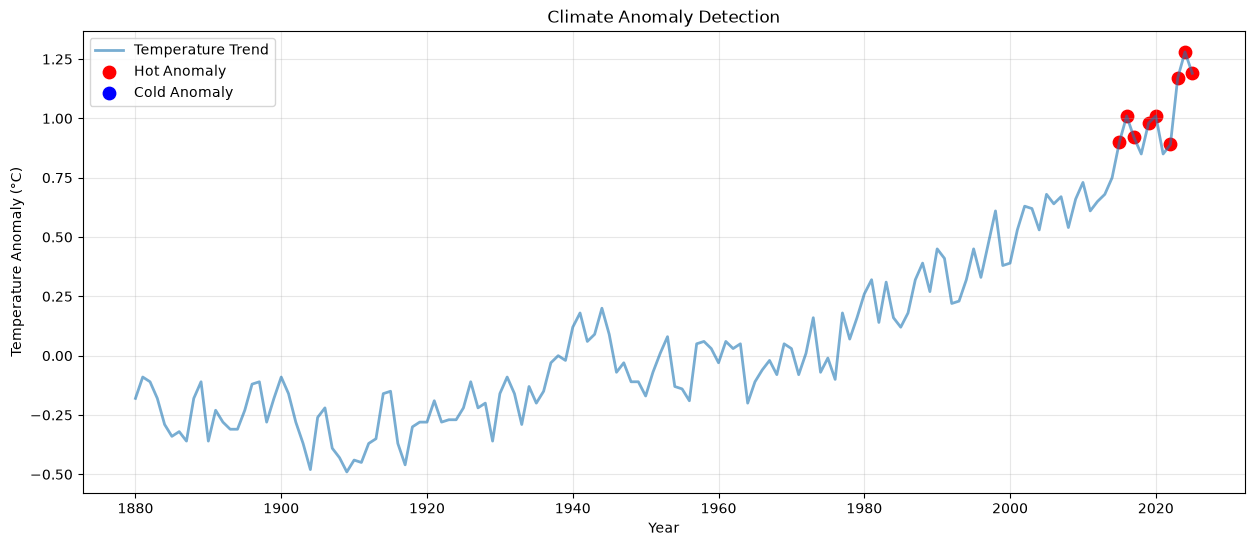

In [71]:
from pathlib import Path

import matplotlib.pyplot as plt

GRAPHS_DIR = root / "graphs"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(15,6))

plt.plot(
    anomaly_df["Year"],
    anomaly_df["Temperature_Anomaly"],
    linewidth=2,
    alpha=0.6,
    label="Temperature Trend"
)

hot = anomaly_df[
    anomaly_df["Anomaly_Type"] == "Hot Anomaly"
]

cold = anomaly_df[
    anomaly_df["Anomaly_Type"] == "Cold Anomaly"
]

plt.scatter(
    hot["Year"],
    hot["Temperature_Anomaly"],
    color="red",
    s=80,
    label="Hot Anomaly"
)

plt.scatter(
    cold["Year"],
    cold["Temperature_Anomaly"],
    color="blue",
    s=80,
    label="Cold Anomaly"
)

plt.title("Climate Anomaly Detection")

plt.xlabel("Year")

plt.ylabel("Temperature Anomaly (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR / "anomaly_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [72]:
summary = pd.DataFrame({
    "Metric": [
        "Total Years",
        "Hot Anomalies",
        "Cold Anomalies",
        "Normal Years"
    ],
    "Value": [
        len(anomaly_df),
        len(hot),
        len(cold),
        len(anomaly_df) - len(hot) - len(cold)
    ]
})

summary

,Metric,Value
0,Total Years,146
1,Hot Anomalies,9
2,Cold Anomalies,0
3,Normal Years,137


In [73]:
summary.to_csv(
    TABLES_DIR / "anomaly_summary.csv",
    index=False
)

In [84]:
from src.anomaly_detection import detect_anomalies

from src.anomaly_detection import detect_anomalies  # noqa: F401


In [86]:
def detect_iqr_anomalies(df, column="Temperature_Anomaly", multiplier=1.5):
    data = df.copy()
    data = data.dropna(subset=[column]).copy()

    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr

    data["IQR_Lower"] = lower_bound
    data["IQR_Upper"] = upper_bound
    data["IQR_Anomaly"] = data[column].lt(lower_bound) | data[column].gt(upper_bound)
    data["IQR_Anomaly_Type"] = data["IQR_Anomaly"].map(
        {True: "Outlier", False: "Normal"}
    )

    return data

iqr_df = detect_iqr_anomalies(trend_clean)

iqr_df.head()

,Year,Temperature_Anomaly,IQR_Lower,IQR_Upper,IQR_Anomaly,IQR_Anomaly_Type
0,1880,-0.18,-0.97625,1.09375,False,Normal
1,1881,-0.09,-0.97625,1.09375,False,Normal
2,1882,-0.11,-0.97625,1.09375,False,Normal
3,1883,-0.18,-0.97625,1.09375,False,Normal
4,1884,-0.29,-0.97625,1.09375,False,Normal


In [87]:
iqr_years = iqr_df[
    iqr_df["IQR_Anomaly"]
]

iqr_years.to_csv(
    TABLES_DIR /
    "iqr_anomalies.csv",
    index=False
)

In [88]:
comparison = anomaly_df.copy()

comparison["IQR_Anomaly"] = (
    iqr_df["IQR_Anomaly"]
)

In [89]:
comparison["Detection"] = "None"

comparison.loc[
    comparison["Anomaly"] &
    comparison["IQR_Anomaly"],
    "Detection"
] = "Both"

comparison.loc[
    comparison["Anomaly"] &
    ~comparison["IQR_Anomaly"],
    "Detection"
] = "Z-Score Only"

comparison.loc[
    ~comparison["Anomaly"] &
    comparison["IQR_Anomaly"],
    "Detection"
] = "IQR Only"

In [90]:
comparison.to_csv(
    TABLES_DIR /
    "anomaly_comparison.csv",
    index=False
)

In [91]:
comparison["Detection"].value_counts()

Detection
None            137
Z-Score Only      6
Both              3
Name: count, dtype: int64

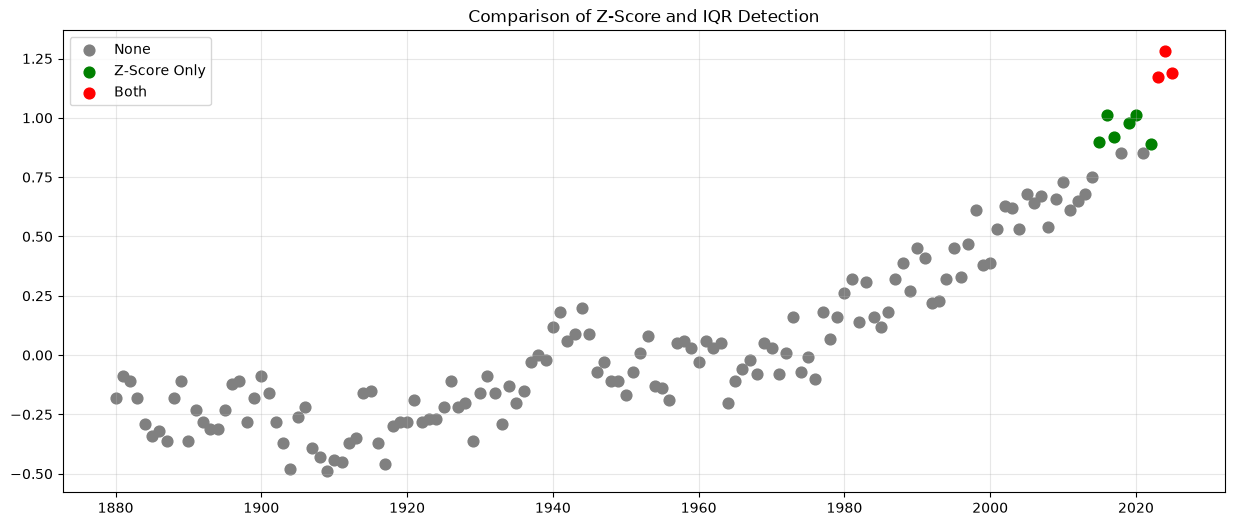

In [92]:
plt.figure(figsize=(15,6))

colors = {
    "None":"gray",
    "Both":"red",
    "IQR Only":"blue",
    "Z-Score Only":"green"
}

for category in comparison["Detection"].unique():

    subset = comparison[
        comparison["Detection"] == category
    ]

    plt.scatter(
        subset["Year"],
        subset["Temperature_Anomaly"],
        label=category,
        color=colors[category],
        s=60
    )

plt.legend()

plt.grid(alpha=0.3)

plt.title(
    "Comparison of Z-Score and IQR Detection"
)

plt.savefig(
    GRAPHS_DIR /
    "zscore_vs_iqr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()